In [ ]:
import pandas as pd
import geopandas as gpd

tract_data   = pd.read_csv("Fqhc-2025.csv")
min_dis_data = pd.read_csv("2025_tract_Fqhc_MinDis.csv")
tract_data.head()

,HEROP_ID,FIPS,FqhcCntDr,FqhcTmDr2,FqhcTmDr
0,140US01001020100,1001020100,9.0,42.46,21.23
1,140US01001020200,1001020200,9.0,39.60,19.80
2,140US01001020300,1001020300,9.0,36.16,18.08
3,140US01001020400,1001020400,9.0,34.10,17.05
4,140US01001020500,1001020500,NaN,NaN,NaN


,HEROP_ID,FqhcMinDis
0,140US01089011021,0.484831
1,140US01095031200,2.666130
2,140US01073012401,3.624983
3,140US01073003400,0.549765
4,140US01073010402,0.890015


In [ ]:
crosswalk = pd.read_csv("/content/ZIP_TRACT.csv")
crosswalk.head()

,ZIP,TRACT,USPS_ZIP_PREF_CITY,USPS_ZIP_PREF_STATE,RES_RATIO,BUS_RATIO,OTH_RATIO,TOT_RATIO
0,501,36103158607,HOLTSVILLE,NY,0.000000,1.000000,0.000000,1.000000
1,601,72001956700,ADJUNTAS,PR,0.758369,0.661616,0.557576,0.747285
2,601,72001956800,ADJUNTAS,PR,0.050297,0.015152,0.054545,0.048247
3,601,72001956600,ADJUNTAS,PR,0.173832,0.318182,0.375758,0.187868
4,601,72001956500,ADJUNTAS,PR,0.014953,0.000000,0.000000,0.013652


In [ ]:
min_dis_data = min_dis_data[["HEROP_ID", 'FqhcMinDis']]

# Normalize HEROP_ID on both sides
min_dis_data["HEROP_ID"] = min_dis_data["HEROP_ID"].astype(str).str.strip()
tract_data["HEROP_ID"]   = tract_data["HEROP_ID"].astype(str).str.strip()


In [ ]:
TRACT_SHP_PATH = "/content/tract-2022-500k-shp.zip"  # <-- update this path

print("Loading tract shapefile...")
tract_geo = gpd.read_file(TRACT_SHP_PATH)

print(f"Loaded! Total tracts: {len(tract_geo)}")
print(f"Columns: {tract_geo.columns.tolist()}")
tract_geo.head(3)

Loading tract shapefile...
Loaded! Total tracts: 85185
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'AFFGEOID', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'HEROP_ID', 'minx', 'miny', 'maxx', 'maxy', 'BBOX', 'LABEL', 'geometry']


,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,...,ALAND,AWATER,HEROP_ID,minx,miny,maxx,maxy,BBOX,LABEL,geometry
0,01,089,003100,1400000US01089003100,01089003100,31,Census Tract 31,AL,Madison County,Alabama,...,4284351,50648,140US01089003100,-86.600244,34.719475,-86.573611,34.740912,"-86.6,34.719,-86.574,34.741",Census Tract 31,"POLYGON ((-86.59838 34.74091, -86.58937 34.739..."
1,01,089,000501,1400000US01089000501,01089000501,5.01,Census Tract 5.01,AL,Madison County,Alabama,...,2804806,0,140US01089000501,-86.657027,34.771281,-86.616584,34.779537,"-86.657,34.771,-86.617,34.78",Census Tract 5.01,"POLYGON ((-86.65703 34.77881, -86.65458 34.778..."
2,01,089,011021,1400000US01089011021,01089011021,110.21,Census Tract 110.21,AL,Madison County,Alabama,...,11286806,55504,140US01089011021,-86.786928,34.662612,-86.738957,34.701062,"-86.787,34.663,-86.739,34.701",Census Tract 110.21,"POLYGON ((-86.78678 34.67045, -86.78667 34.676..."


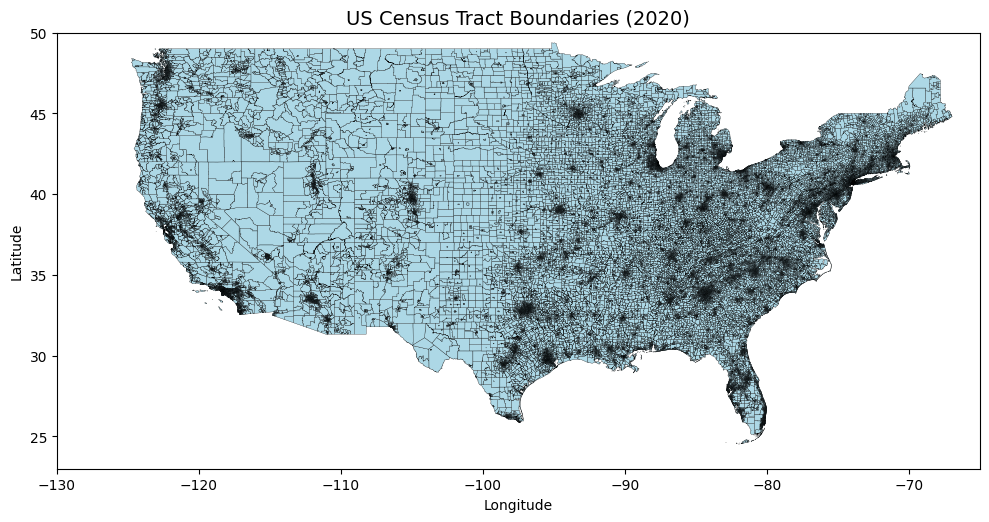

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))

tract_geo.plot(
    ax=ax,
    color="lightblue",    # fill color
    edgecolor="black",    # boundary color
    linewidth=0.2
)

ax.set_xlim(-130, -65)   # continental US longitude range
ax.set_ylim(23, 50)      # continental US latitude range
ax.set_title("US Census Tract Boundaries (2020)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [ ]:
tract_w_dis = min_dis_data.merge(tract_data, on="HEROP_ID", how="left")
tract_w_dis.head()

,HEROP_ID,FqhcMinDis,FIPS,FqhcCntDr,FqhcTmDr2,FqhcTmDr
0,140US01089011021,0.484831,1.089011e+09,11.0,28.54,14.27
1,140US01095031200,2.666130,1.095031e+09,6.0,23.02,11.51
2,140US01073012401,3.624983,1.073012e+09,23.0,16.12,8.06
3,140US01073003400,0.549765,1.073003e+09,23.0,0.00,0.00
4,140US01073010402,0.890015,1.073010e+09,24.0,0.00,0.00


In [ ]:
# Ensure GEOID (from tract_w_dis) and TRACT (from crosswalk) are strings
# Zero-padded to 11 digits to ensure correct matching during merge
# e.g. GEOID 1073003400 becomes 01073003400
tract_w_dis["HEROP_ID"] = tract_w_dis["HEROP_ID"].astype(str).str.strip().str.zfill(11)
crosswalk["TRACT"] = crosswalk["TRACT"].astype(str).str.strip().str.zfill(11)

In [ ]:
# Diagnostic - check if keys actually match
print("Sample tract_w_dis GEOIDs:")
print(tract_w_dis['HEROP_ID'].head(10).tolist())

print("\nSample crosswalk TRACTs:")
print(crosswalk['TRACT'].head(10).tolist())

print("\nAny matches?")
common = set(tract_w_dis['GEOID']).intersection(set(crosswalk['TRACT']))
print(f"Number of matching keys: {len(common)}")
print("Sample matches:", list(common)[:5])

Sample tract_w_dis GEOIDs:
['140US01089011021', '140US01095031200', '140US01073012401', '140US01073003400', '140US01073010402', '140US01073005101', '140US01073000500', '140US01073010705', '140US01103001000', '140US01125011701']

Sample crosswalk TRACTs:
['36103158607', '72001956700', '72001956800', '72001956600', '72001956500', '72081958400', '72003430300', '72003430200', '72005400300', '72003430501']

Any matches?
Number of matching keys: 0
Sample matches: []


In [ ]:
# Step 1: Create a clean tract ID (remove "140US")
tract_w_dis['TRACT'] = tract_w_dis['HEROP_ID'].str.replace('^140US', '', regex=True)

# Optional: ensure both are strings
tract_w_dis['TRACT'] = tract_w_dis['TRACT'].astype(str)
crosswalk['TRACT'] = crosswalk['TRACT'].astype(str).str.zfill(11)

# Step 2: Diagnostic check again
common = set(tract_w_dis['TRACT']).intersection(set(crosswalk['TRACT']))
print(f"Number of matching keys after cleaning: {len(common)}")
print("Sample matches:", list(common)[:5])

Number of matching keys after cleaning: 84055
Sample matches: ['53041971600', '20091051912', '26079950601', '26163517000', '26125161200']


In [ ]:
print(tract_w_dis['TRACT'].str.len().value_counts())
print(crosswalk['TRACT'].str.len().value_counts())

TRACT
11    85187
Name: count, dtype: int64
TRACT
11    189375
Name: count, dtype: int64


In [ ]:
# Merge the combined tract data (tract_w_dis) with the ZIP crosswalk
# using left join to retain all tracts, even those without a ZIP match
# Unmatched tracts will have NaN for ZIP and ratio columns
merged = pd.merge(tract_w_dis, crosswalk, left_on="TRACT", right_on="TRACT", how="left")
merged.head()

,HEROP_ID,FqhcMinDis,FIPS,FqhcCntDr,FqhcTmDr2,FqhcTmDr,GEOID,TRACT,ZIP,USPS_ZIP_PREF_CITY,USPS_ZIP_PREF_STATE,RES_RATIO,BUS_RATIO,OTH_RATIO,TOT_RATIO
0,140US01089011021,0.484831,1.089011e+09,11.0,28.54,14.27,140US01089011021,01089011021,35758.0,MADISON,AL,0.117294,0.220721,0.135870,0.127179
1,140US01095031200,2.666130,1.095031e+09,6.0,23.02,11.51,140US01095031200,01095031200,35950.0,ALBERTVILLE,AL,0.000106,0.000000,0.000000,0.000092
2,140US01095031200,2.666130,1.095031e+09,6.0,23.02,11.51,140US01095031200,01095031200,35956.0,BOAZ,AL,0.001446,0.000000,0.000000,0.001385
3,140US01095031200,2.666130,1.095031e+09,6.0,23.02,11.51,140US01095031200,01095031200,35957.0,BOAZ,AL,0.327736,0.689057,0.674419,0.370454
4,140US01073012401,3.624983,1.073012e+09,23.0,16.12,8.06,140US01073012401,01073012401,35214.0,BIRMINGHAM,AL,0.168812,0.202593,0.189516,0.171215


In [ ]:
# Diagnostic - understand what's happening after merge
print("Shape of merged dataframe:", merged.shape)
print("\nNull counts in key columns:")
print(merged[['FqhcTmDr', 'FqhcTmDr2', 'FqhcCntDr', 'FqhcMinDis', 'RES_RATIO']].isnull().sum())

print("\nRows where RES_RATIO is NaN (unmatched tracts):", merged['RES_RATIO'].isna().sum())
print("Rows where RES_RATIO is NOT NaN (matched tracts):", merged['RES_RATIO'].notna().sum())

print("\nSample of merged data:")
print(merged[['GEOID', 'TRACT', 'ZIP', 'RES_RATIO', 'FqhcTmDr', 'FqhcCntDr', 'FqhcMinDis']].head(10))

Shape of merged dataframe: (188756, 15)

Null counts in key columns:
FqhcTmDr      10319
FqhcTmDr2     10319
FqhcCntDr      6256
FqhcMinDis        0
RES_RATIO      1132
dtype: int64

Rows where RES_RATIO is NaN (unmatched tracts): 1132
Rows where RES_RATIO is NOT NaN (matched tracts): 187624

Sample of merged data:
              GEOID        TRACT      ZIP  RES_RATIO  FqhcTmDr  FqhcCntDr  \
0  140US01089011021  01089011021  35758.0   0.117294     14.27       11.0   
1  140US01095031200  01095031200  35950.0   0.000106     11.51        6.0   
2  140US01095031200  01095031200  35956.0   0.001446     11.51        6.0   
3  140US01095031200  01095031200  35957.0   0.327736     11.51        6.0   
4  140US01073012401  01073012401  35214.0   0.168812      8.06       23.0   
5  140US01073003400  01073003400  35218.0   0.290611      0.00       23.0   
6  140US01073010402  01073010402  35020.0   0.033274      0.00       24.0   
7  140US01073010402  01073010402  35022.0   0.050484      0.00     

In [ ]:
# Drop rows where RES_RATIO is NaN
# These are tracts that had no matching ZIP in the crosswalk
# Kept the left join above intentionally to first inspect unmatched tracts if needed
merged = merged.dropna(subset=["RES_RATIO"])

In [ ]:
# Multiply each tract-level metric by RES_RATIO (residential ratio)
# RES_RATIO = proportion of the tract residents that fall in a given ZIP
# This weights each tract's contribution proportionally before aggregating to ZIP level
# FqhcTmDr  : Drive time (in minutes) to nearest Fqhcrexone facility
# FqhcTmDr2 : Drive time x2 (round trip)
# FqhcCntDr : Count of Fqhcrexone facilities reachable within 30 min drive
# FqhcMinDis: Minimum distance (miles) to nearest Fqhcrexone facility
merged["FqhcTmDr_wt"]  = merged["FqhcTmDr"]  * merged["RES_RATIO"]
merged["FqhcTmDr2_wt"] = merged["FqhcTmDr2"] * merged["RES_RATIO"]
merged["FqhcCntDr_wt"] = merged["FqhcCntDr"] * merged["RES_RATIO"]
merged["FqhcMinDis_wt"] = merged["FqhcMinDis"] * merged["RES_RATIO"]

In [ ]:
# Aggregate all weighted metrics to ZIP level by summing
# Also sum RES_RATIO per ZIP — this serves as the total weight denominator
# for computing the weighted average in the next step
zip_agg = merged.groupby("ZIP").agg({
    "FqhcTmDr_wt" : "sum",
    "FqhcTmDr2_wt": "sum",
    "FqhcCntDr_wt": "sum",
    "FqhcMinDis_wt": "sum",
    "RES_RATIO"  : "sum"   # sum of weights per ZIP
}).reset_index()

In [ ]:
# Compute final weighted averages by dividing each weighted sum by the total weight (RES_RATIO sum)
# Formula: weighted_avg = sum(metric * RES_RATIO) / sum(RES_RATIO)
# This gives the population-weighted average value of each metric for each ZIP
zip_agg["FqhcTmDr"]  = zip_agg["FqhcTmDr_wt"]  / zip_agg["RES_RATIO"]
zip_agg["FqhcTmDr2"] = zip_agg["FqhcTmDr2_wt"] / zip_agg["RES_RATIO"]
zip_agg["FqhcCntDr"] = zip_agg["FqhcCntDr_wt"] / zip_agg["RES_RATIO"]
zip_agg["FqhcMinDis"] = zip_agg["FqhcMinDis_wt"] / zip_agg["RES_RATIO"]

In [ ]:
# Fix ZIP format: ZIP was stored as float (e.g. 6001.0) due to NaN rows during merge
# Convert to int first to remove decimal, then to string, then zero-pad to 5 digits
# This preserves leading zeros for ZIPs like 06001 (New England ZIPs)
zip_agg["ZIP"] = zip_agg["ZIP"].astype(int).astype(str).str.zfill(5)

# Select final columns for output
# FqhcTmDr  : Weighted avg drive time to nearest Fqhcrexone facility (minutes)
# FqhcTmDr2 : Weighted avg round-trip drive time (minutes)
# FqhcCntDr : Weighted avg count of facilities reachable within 30 min
# FqhcMinDis: Weighted avg minimum distance to nearest facility (miles)
result = zip_agg[["ZIP", "FqhcTmDr", "FqhcTmDr2", "FqhcCntDr", "FqhcMinDis"]]
result.head()

,ZIP,FqhcTmDr,FqhcTmDr2,FqhcCntDr,FqhcMinDis
0,00501,NaN,NaN,NaN,NaN
1,00601,0.0,0.0,0.0,0.839626
2,00602,0.0,0.0,0.0,0.764795
3,00603,0.0,0.0,0.0,1.230732
4,00604,0.0,0.0,0.0,3.390285


In [ ]:
# Save final ZIP-level result to CSV
result.to_csv("Fqhc_zip25.csv", index=False)


In [ ]:
!pip install openpyxl
result.to_excel("Fqhc-ZIP25.xlsx", index=False)
# Then format ZIP column as Text in Excel

In [ ]:
# ── Visualization Setup ──────────────────────────────────────────────────────
# geopandas : read shapefiles and plot choropleth maps
# mapclassify: required for fisher_jenks classification scheme
# matplotlib : plotting
!pip install geopandas mapclassify matplotlib -q

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

print("Libraries loaded!")

Libraries loaded!


In [ ]:
ZCTA_SHP_PATH = "/content/zcta-2020-500k-shp.zip"  # update this path
zcta_geo = gpd.read_file(ZCTA_SHP_PATH)

In [ ]:

# Identify the ZIP key column in the ZCTA shapefile
zip_col = [c for c in zcta_geo.columns if "ZCTA" in c.upper() or c == "GEOID"][0]
#print(f"Joining on column: {zip_col}")

# Ensure both sides are 5-digit zero-padded strings
zcta_geo[zip_col] = zcta_geo[zip_col].astype(str).str.zfill(5)
result["ZIP"] = result["ZIP"].astype(str).str.zfill(5)

# Merge ZIP-level result with ZCTA geometry
zcta_merged = zcta_geo.merge(result, left_on=zip_col, right_on="ZIP", how="left")
#print(f"ZCTAs with MetTmDr data: {zcta_merged['MetTmDr'].notna().sum()} / {len(zcta_merged)}")



/tmp/ipykernel_2816/3657972724.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result["ZIP"] = result["ZIP"].astype(str).str.zfill(5)


In [ ]:
zcta_merged

,ZCTA5CE20,AFFGEOID20,GEOID20,NAME20,LSAD20,ALAND20,AWATER20,HEROP_ID,minx,miny,maxx,maxy,BBOX,LABEL,geometry,ZIP,FqhcTmDr,FqhcTmDr2,FqhcCntDr,FqhcMinDis
0,15301,860Z200US15301,15301,15301,Z5,315861121,709775,860US15301,-80.368598,40.044189,-80.130902,40.282151,"-80.369,40.044,-80.131,40.282",15301,"POLYGON ((-80.3686 40.21895, -80.35493 40.2440...",15301,2.384748,4.769496,29.005371,1.572527
1,15658,860Z200US15658,15658,15658,Z5,238683518,759690,860US15658,-79.343230,40.156005,-79.055115,40.357548,"-79.343,40.156,-79.055,40.358",15658,"POLYGON ((-79.34323 40.17201, -79.3375 40.1777...",15658,19.021904,38.043808,1.628427,10.662944
2,15601,860Z200US15601,15601,15601,Z5,208874774,337008,860US15601,-79.669111,40.214076,-79.435129,40.450345,"-79.669,40.214,-79.435,40.45",15601,"POLYGON ((-79.66911 40.28912, -79.6626 40.2858...",15601,4.844588,9.689176,7.714014,2.369906
3,17720,860Z200US17720,17720,17720,Z5,8797202,2822,860US17720,-77.230264,41.166952,-77.177409,41.193036,"-77.23,41.167,-77.177,41.193",17720,"POLYGON ((-77.23026 41.18926, -77.2249 41.1904...",17720,5.560000,11.120000,2.000000,3.155655
4,18843,860Z200US18843,18843,18843,Z5,3620019,0,860US18843,-75.908030,41.787190,-75.882120,41.821749,"-75.908,41.787,-75.882,41.822",18843,"POLYGON ((-75.90554 41.79017, -75.90545 41.792...",18843,0.000000,0.000000,3.000000,0.605171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33786,79837,860Z200US79837,79837,79837,Z5,2816585533,13321362,860US79837,-105.661092,31.745372,-104.847742,32.341740,"-105.661,31.745,-104.848,32.342",79837,"POLYGON ((-105.65967 32.22826, -105.65924 32.2...",79837,0.000000,0.000000,3.000000,19.016804
33787,88338,860Z200US88338,88338,88338,Z5,410220035,0,860US88338,-105.524524,33.424905,-105.243363,33.651833,"-105.525,33.425,-105.243,33.652",88338,"POLYGON ((-105.52452 33.49586, -105.5228 33.49...",88338,44.165437,88.330874,0.000000,28.985983
33788,40475,860Z200US40475,40475,40475,Z5,744211584,10950035,860US40475,-84.525643,37.622933,-84.091775,37.917546,"-84.526,37.623,-84.092,37.918",40475,"POLYGON ((-84.52564 37.7695, -84.52383 37.7707...",40475,13.105095,26.210190,17.221108,2.916911
33789,99738,860Z200US99738,99738,99738,Z5,26066302603,325892484,860US99738,-144.247429,64.026902,-141.001312,66.142776,"-144.247,64.027,-141.001,66.143",99738,"POLYGON ((-144.24532 64.47211, -144.23448 64.4...",99738,0.000000,0.000000,7.000000,37.693706


In [ ]:
#Visualizing  ZCTA
import matplotlib.pyplot as plt

def visualize_geographies_geodataframe(gdf, title="Geography Visualization", points_only=False):
    gdf = gdf.to_crs(epsg=4326).copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    if points_only:
        gdf_proj = gdf.to_crs(epsg=5070)
        centroids = gdf_proj.centroid.to_crs(epsg=4326)

        ax.scatter(
            centroids.x,
            centroids.y,
            s=8,
            color="red",
            alpha=0.7
        )
    else:
        gdf.plot(ax=ax, color="lightblue", edgecolor="black", linewidth=0.2)

    ax.set_xlim(-130, -65)
    ax.set_ylim(23, 50)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title, fontsize=14)
    plt.show()

    return gdf

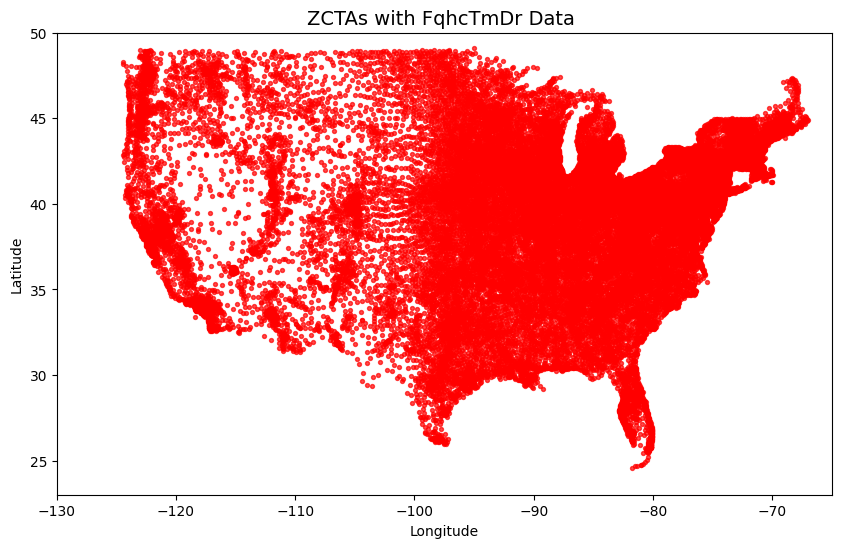

,ZCTA5CE20,AFFGEOID20,GEOID20,NAME20,LSAD20,ALAND20,AWATER20,HEROP_ID,minx,miny,maxx,maxy,BBOX,LABEL,geometry,ZIP,FqhcTmDr,FqhcTmDr2,FqhcCntDr,FqhcMinDis
0,15301,860Z200US15301,15301,15301,Z5,315861121,709775,860US15301,-80.368598,40.044189,-80.130902,40.282151,"-80.369,40.044,-80.131,40.282",15301,"POLYGON ((-80.3686 40.21895, -80.35493 40.2440...",15301,2.384748,4.769496,29.005371,1.572527
1,15658,860Z200US15658,15658,15658,Z5,238683518,759690,860US15658,-79.343230,40.156005,-79.055115,40.357548,"-79.343,40.156,-79.055,40.358",15658,"POLYGON ((-79.34323 40.17201, -79.3375 40.1777...",15658,19.021904,38.043808,1.628427,10.662944
2,15601,860Z200US15601,15601,15601,Z5,208874774,337008,860US15601,-79.669111,40.214076,-79.435129,40.450345,"-79.669,40.214,-79.435,40.45",15601,"POLYGON ((-79.66911 40.28912, -79.6626 40.2858...",15601,4.844588,9.689176,7.714014,2.369906
3,17720,860Z200US17720,17720,17720,Z5,8797202,2822,860US17720,-77.230264,41.166952,-77.177409,41.193036,"-77.23,41.167,-77.177,41.193",17720,"POLYGON ((-77.23026 41.18926, -77.2249 41.1904...",17720,5.560000,11.120000,2.000000,3.155655
4,18843,860Z200US18843,18843,18843,Z5,3620019,0,860US18843,-75.908030,41.787190,-75.882120,41.821749,"-75.908,41.787,-75.882,41.822",18843,"POLYGON ((-75.90554 41.79017, -75.90545 41.792...",18843,0.000000,0.000000,3.000000,0.605171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33786,79837,860Z200US79837,79837,79837,Z5,2816585533,13321362,860US79837,-105.661092,31.745372,-104.847742,32.341740,"-105.661,31.745,-104.848,32.342",79837,"POLYGON ((-105.65967 32.22826, -105.65924 32.2...",79837,0.000000,0.000000,3.000000,19.016804
33787,88338,860Z200US88338,88338,88338,Z5,410220035,0,860US88338,-105.524524,33.424905,-105.243363,33.651833,"-105.525,33.425,-105.243,33.652",88338,"POLYGON ((-105.52452 33.49586, -105.5228 33.49...",88338,44.165437,88.330874,0.000000,28.985983
33788,40475,860Z200US40475,40475,40475,Z5,744211584,10950035,860US40475,-84.525643,37.622933,-84.091775,37.917546,"-84.526,37.623,-84.092,37.918",40475,"POLYGON ((-84.52564 37.7695, -84.52383 37.7707...",40475,13.105095,26.210190,17.221108,2.916911
33789,99738,860Z200US99738,99738,99738,Z5,26066302603,325892484,860US99738,-144.247429,64.026902,-141.001312,66.142776,"-144.247,64.027,-141.001,66.143",99738,"POLYGON ((-144.24532 64.47211, -144.23448 64.4...",99738,0.000000,0.000000,7.000000,37.693706


In [ ]:
zcta_with_data = zcta_merged[zcta_merged["FqhcTmDr"].notna()].copy()

visualize_geographies_geodataframe(
    zcta_with_data,
    title="ZCTAs with FqhcTmDr Data ",
    points_only=True
)

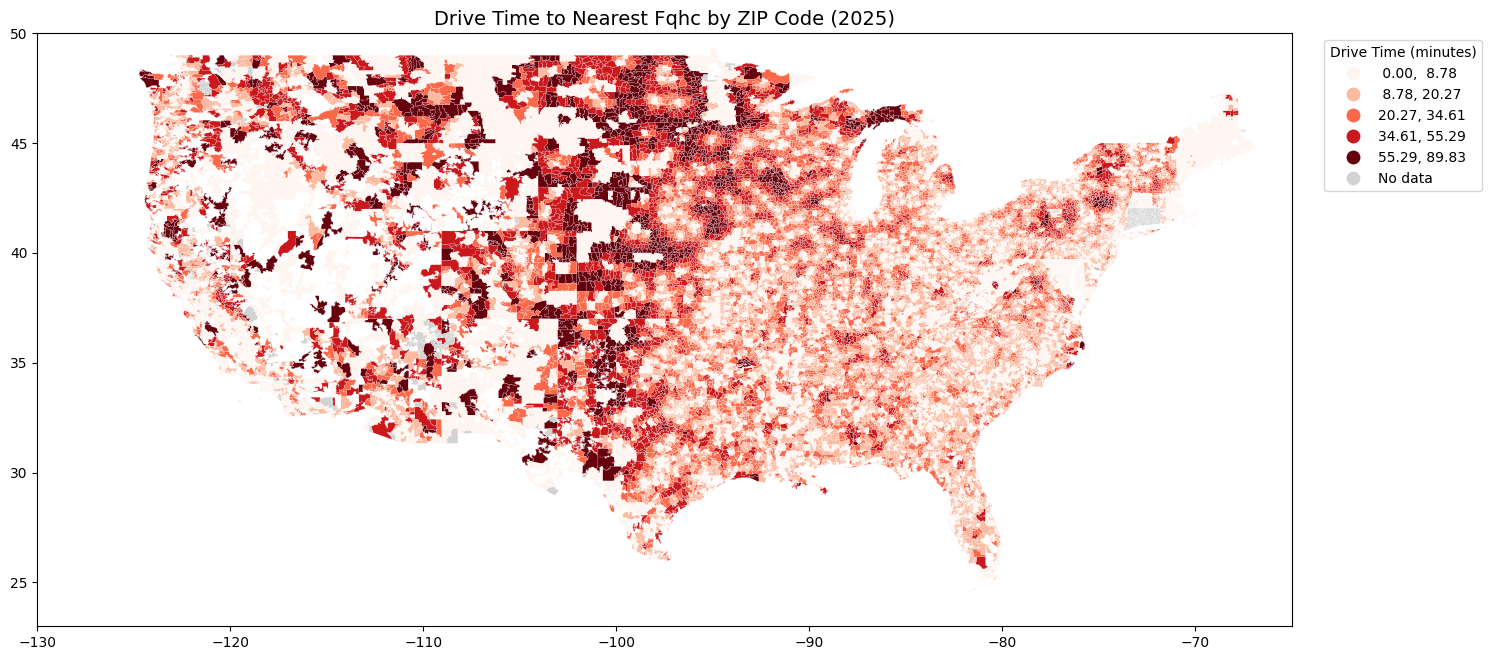

In [ ]:
# Plot choropleth
fig, ax = plt.subplots(figsize=(15, 9))

zcta_merged.plot(
    ax=ax,
    column="FqhcTmDr",
    cmap="Reds",
    scheme="fisher_jenks",   # natural breaks classification
    k=5,                      # 5 classes
    edgecolor="white",
    linewidth=0.1,
    legend=True,
    legend_kwds={
        "title": "Drive Time (minutes)",
        "loc": "upper left",
        "bbox_to_anchor": (1.02, 1.0),  # push legend outside map
        "frameon": True
    },
    missing_kwds={"color": "lightgrey", "label": "No data"}  # NaN ZIPs in grey
)

ax.set_xlim(-130, -65)   # continental US longitude
ax.set_ylim(23, 50)      # continental US latitude
ax.set_title("Drive Time to Nearest Fqhc by ZIP Code (2025)", fontsize=14)
plt.tight_layout()
plt.show()